# Lab 2 Starter: Predicting Late Invoice Payments (Accounts Receivable)

This notebook is a guided starter for **Lab 2** in the ERP + AI course.

## Business Context

In ERP systems, the **Accounts Receivable (AR)** module manages customer invoices and payments. Companies often want to **predict which invoices are likely to be paid late** so they can:

- prioritize collections
- adjust credit policies
- reduce cash-flow risk

In this lab, we build a **machine learning classification model** that predicts whether an invoice will be paid late.

## Learning Objectives

By the end of this lab, you should be able to:

- understand how machine learning can support ERP financial processes
- perform feature engineering on business data
- train and evaluate a classification model
- interpret results in business terms

## Dataset

This notebook assumes the IBM Accounts Receivable dataset file is named:

`WA_Fn-UseC_-Accounts-Receivable.csv`

> Important: real business datasets often have messy column names. If your dataset uses slightly different field names, you may need to adjust this notebook.

## Step 1. Import Libraries

We begin by importing the Python libraries needed for:

- data loading and manipulation
- visualization
- train/test split
- machine learning models
- evaluation metrics

Read the inline comments carefully. They explain why each library is imported.

In [9]:
# ============================================================
# STEP 1: IMPORT LIBRARIES
# ============================================================

# pandas is used for working with tables of data (DataFrames)
import pandas as pd

# numpy is used for numerical operations
import numpy as np

# matplotlib is the basic plotting library
import matplotlib.pyplot as plt

# seaborn makes plots look nicer and easier to create
import seaborn as sns

# train_test_split is used to split data into training and testing sets
from sklearn.model_selection import train_test_split

# StandardScaler can be used to scale numeric features
# We import it here for completeness, though it is optional in this notebook
from sklearn.preprocessing import StandardScaler

# Evaluation metrics for classification
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay
)

# Two classification models:
# 1. Logistic Regression - a simple and common baseline classifier
# 2. Random Forest - a stronger tree-based ensemble model
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# This line tells matplotlib to display plots inside the notebook
%matplotlib inline

## Step 2. Load the Dataset from Google Drive

In Google Colab, one easy way to work with a CSV file is to read it from your Google Drive.

This will:
1. select the CSV file from your Google Drive
2. load it into a pandas DataFrame

After loading, we preview the first few rows to make sure the file was read correctly.

In [10]:
# # ============================================================
# # STEP 2: UPLOAD THE DATASET IN COLAB
# # ============================================================

# import pandas as pd
# from google.colab import drive
# import os

# drive.mount('/content/drive')

# # Update the path to your file in Google Drive
# folder_path = "/content/drive/My Drive/Teaching/CPE494/Labs/"
# file_name = "WA_Fn-UseC_-Accounts-Receivable.csv"
# file_path = folder_path + file_name

# # Check if the file exists at the specified path
# if os.path.exists(file_path):

#     print("Reading dataset file...")
#     # Read the CSV file into a pandas DataFrame
#     df = pd.read_csv(file_path)
#     print("...done reading dataset file")

#     #show the first 5 rows to inspect the data
#     print(df.head())

# else:
#     print(f"Error: File not found at {file_path}")
#     print("Please check the path and filename.")

#     # List contents of the directory to help debug
#     directory_path = os.path.dirname(file_path)
#     if os.path.exists(directory_path):
#         print(f"Contents of directory '{directory_path}':")
#         for item in os.listdir(directory_path):
#             print(f"- {item}")
#     else:
#         print(f"Error: Directory '{directory_path}' not found.")

In [11]:
# ============================================================
# STEP 2: DOWNLOAD THE DATASET
# ============================================================

import pandas as pd
import os

# Update the path to your file
folder_path = "data/"
file_name = "WA_Fn-UseC_-Accounts-Receivable.csv"
file_path = folder_path + file_name

# Check if the file exists at the specified path
if os.path.exists(file_path):

    print("Reading dataset file...")
    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(file_path)
    print("...done reading dataset file")

    #show the first 5 rows to inspect the data
    print(df.head())

else:
    print(f"Error: File not found at {file_path}")
    print("Please check the path and filename.")

    # List contents of the directory to help debug
    directory_path = os.path.dirname(file_path)
    if os.path.exists(directory_path):
        print(f"Contents of directory '{directory_path}':")
        for item in os.listdir(directory_path):
            print(f"- {item}")
    else:
        print(f"Error: Directory '{directory_path}' not found.")

Reading dataset file...
...done reading dataset file
   countryCode  customerID PaperlessDate  invoiceNumber InvoiceDate  \
0          391  0379-NEVHP      4/6/2013         611365    1/2/2013   
1          406  8976-AMJEO      3/3/2012        7900770   1/26/2013   
2          391  2820-XGXSB     1/26/2012        9231909    7/3/2013   
3          406  9322-YCTQO      4/6/2012        9888306   2/10/2013   
4          818  6627-ELFBK    11/26/2012       15752855  10/25/2012   

      DueDate  InvoiceAmount Disputed SettledDate PaperlessBill  DaysToSettle  \
0    2/1/2013          55.94       No   1/15/2013         Paper            13   
1   2/25/2013          61.74      Yes    3/3/2013    Electronic            36   
2    8/2/2013          65.88       No    7/8/2013    Electronic             5   
3   3/12/2013         105.92       No   3/17/2013    Electronic            35   
4  11/24/2012          72.27      Yes  11/28/2012         Paper            34   

   DaysLate  
0         0  
1    

## Step 3. Inspect the Dataset Structure

Before building any model, always inspect the dataset.

We want to know:

- how many rows and columns there are
- the names of the columns
- the data types of each column
- whether there are missing values
- whether the numeric columns look reasonable

This is a critical step in any real ERP or business analytics project. Humans love skipping it and then blaming the model later.

In [12]:
# ============================================================
# STEP 3A: BASIC SHAPE AND COLUMN NAMES
# ============================================================

# Display the number of rows and columns
print("Dataset shape:", df.shape)

# Display all column names
print("\nColumn names:")
for col in df.columns:
    print("-", col)

Dataset shape: (2466, 12)

Column names:
- countryCode
- customerID
- PaperlessDate
- invoiceNumber
- InvoiceDate
- DueDate
- InvoiceAmount
- Disputed
- SettledDate
- PaperlessBill
- DaysToSettle
- DaysLate


In [13]:
# ============================================================
# STEP 3B: DATA TYPES AND MISSING VALUES
# ============================================================

# info() shows column names, non-null counts, and data types
print("DataFrame info:")
df.info()

# Count missing values in each column
print("\nMissing values by column:")
print(df.isnull().sum())

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2466 entries, 0 to 2465
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   countryCode    2466 non-null   int64  
 1   customerID     2466 non-null   object 
 2   PaperlessDate  2466 non-null   object 
 3   invoiceNumber  2466 non-null   int64  
 4   InvoiceDate    2466 non-null   object 
 5   DueDate        2466 non-null   object 
 6   InvoiceAmount  2466 non-null   float64
 7   Disputed       2466 non-null   object 
 8   SettledDate    2466 non-null   object 
 9   PaperlessBill  2466 non-null   object 
 10  DaysToSettle   2466 non-null   int64  
 11  DaysLate       2466 non-null   int64  
dtypes: float64(1), int64(4), object(7)
memory usage: 231.3+ KB

Missing values by column:
countryCode      0
customerID       0
PaperlessDate    0
invoiceNumber    0
InvoiceDate      0
DueDate          0
InvoiceAmount    0
Disputed         0
SettledDate      0

In [14]:
# ============================================================
# STEP 3C: DESCRIPTIVE STATISTICS FOR NUMERIC COLUMNS
# ============================================================

# describe() summarizes numeric columns
df.describe()

,countryCode,invoiceNumber,InvoiceAmount,DaysToSettle,DaysLate
count,2466.000000,2.466000e+03,2466.000000,2466.00000,2466.000000
mean,620.446067,4.978431e+09,59.895856,26.44485,3.442417
std,215.933610,2.884272e+09,20.435838,12.33493,6.290607
min,391.000000,6.113650e+05,5.260000,0.00000,0.000000
25%,406.000000,2.528854e+09,46.400000,18.00000,0.000000
50%,770.000000,4.964228e+09,60.560000,26.00000,0.000000
75%,818.000000,7.494512e+09,73.765000,35.00000,5.000000
max,897.000000,9.990244e+09,128.280000,75.00000,45.000000


## Step 4. Understand the Business Problem and Target Variable

The goal is to predict:

- `late_payment = 1` if the invoice was paid late
- `late_payment = 0` if the invoice was paid on time

To do that, we usually need three dates:

- invoice date
- due date
- payment date

From these, we can engineer:

- `days_to_pay` = payment_date - invoice_date
- `allowed_days` = due_date - invoice_date
- `late_payment` = whether `days_to_pay > allowed_days`

Because real datasets may use different column names, the next cell helps inspect likely date-related columns.

In [15]:
# ============================================================
# STEP 4A: LOOK FOR POSSIBLE DATE COLUMNS
# ============================================================

# This is a helper step. It searches for column names that may relate to dates.
# If your dataset has different names than expected, this can help you identify them.

possible_date_cols = [
    col for col in df.columns
    if "date" in col.lower() or "dt" in col.lower()
]

print("Possible date-related columns:")
print(possible_date_cols)

Possible date-related columns:
['PaperlessDate', 'InvoiceDate', 'DueDate', 'SettledDate']


## Step 5. Set the Main Column Names

This notebook assumes the following logical fields exist:

- `invoice_date`
- `due_date`
- `payment_date`
- `invoice_amount`

If your actual dataset uses different names, edit the variables in the next cell.

This makes the rest of the notebook easier to read and modify.

In [16]:
# ============================================================
# STEP 5: DEFINE IMPORTANT COLUMN NAMES
# ============================================================

# IMPORTANT:
# Replace the strings below if your dataset uses different column names.

invoice_date_col = "InvoiceDate"
due_date_col = "DueDate"
payment_date_col = "SettledDate"
invoice_amount_col = "InvoiceAmount"

# Print them so it is easy to confirm
print("Using these columns:")
print("invoice_date_col =", invoice_date_col)
print("due_date_col     =", due_date_col)
print("payment_date_col =", payment_date_col)
print("invoice_amount_col =", invoice_amount_col)

Using these columns:
invoice_date_col = InvoiceDate
due_date_col     = DueDate
payment_date_col = SettledDate
invoice_amount_col = InvoiceAmount


## Step 6. Convert Date Columns to Datetime

Dates often enter a CSV file as plain text. Machine learning models cannot reason about raw date strings.

So we first convert date columns into pandas datetime format.

If this cell throws an error, check whether:

- the column names are correct
- the date values in the file are valid

In [17]:
# ============================================================
# STEP 6: CONVERT DATE COLUMNS TO DATETIME
# ============================================================

# Convert the three key date columns to pandas datetime format
# errors="coerce" means invalid date strings become NaT (missing datetime)
df[invoice_date_col] = pd.to_datetime(df[invoice_date_col], errors="coerce")
df[due_date_col] = pd.to_datetime(df[due_date_col], errors="coerce")
df[payment_date_col] = pd.to_datetime(df[payment_date_col], errors="coerce")

# Display a few rows of the converted columns
df[[invoice_date_col, due_date_col, payment_date_col]].head()

,InvoiceDate,DueDate,SettledDate
0,2013-01-02,2013-02-01,2013-01-15
1,2013-01-26,2013-02-25,2013-03-03
2,2013-07-03,2013-08-02,2013-07-08
3,2013-02-10,2013-03-12,2013-03-17
4,2012-10-25,2012-11-24,2012-11-28


## Step 7. Feature Engineering

Now we create the core business features for the classification problem.

### Features created

- `days_to_pay`: how many days the customer actually took to pay
- `allowed_days`: how many days the customer was allowed to take
- `late_payment`: target label, where 1 means late and 0 means on time
- `invoice_month`: month extracted from invoice date
- `invoice_year`: year extracted from invoice date

Feature engineering is where business understanding meets data science. It is also where many notebooks quietly become nonsense if nobody thinks about what the columns actually mean.

In [18]:
# ============================================================
# STEP 7: CREATE ENGINEERED FEATURES
# ============================================================

# days_to_pay = actual number of days from invoice issue to payment
df["days_to_pay"] = (df[payment_date_col] - df[invoice_date_col]).dt.days

# allowed_days = contractual time allowed before payment is due
df["allowed_days"] = (df[due_date_col] - df[invoice_date_col]).dt.days

# late_payment is our classification target:
# 1 = paid late
# 0 = paid on time
df["late_payment"] = (df["days_to_pay"] > df["allowed_days"]).astype(int)

# Extract month and year from the invoice date
# These can help the model detect seasonal or time-related patterns
df["invoice_month"] = df[invoice_date_col].dt.month
df["invoice_year"] = df[invoice_date_col].dt.year

# Preview the newly created columns
df[[invoice_date_col, due_date_col, payment_date_col,
    "days_to_pay", "allowed_days", "late_payment",
    "invoice_month", "invoice_year"]].head()

,InvoiceDate,DueDate,SettledDate,days_to_pay,allowed_days,late_payment,invoice_month,invoice_year
0,2013-01-02,2013-02-01,2013-01-15,13,30,0,1,2013
1,2013-01-26,2013-02-25,2013-03-03,36,30,1,1,2013
2,2013-07-03,2013-08-02,2013-07-08,5,30,0,7,2013
3,2013-02-10,2013-03-12,2013-03-17,35,30,1,2,2013
4,2012-10-25,2012-11-24,2012-11-28,34,30,1,10,2012


## Step 8. Clean the Modeling Data

Machine learning models generally cannot handle missing values directly.

So before modeling, we keep only rows where the essential fields are present.

We also check the target distribution to see whether the dataset is imbalanced.

In [19]:
# ============================================================
# STEP 8A: KEEP ONLY ROWS NEEDED FOR MODELING
# ============================================================

# These are the minimum columns we need for the starter model
required_cols = [
    invoice_amount_col,
    "days_to_pay",
    "allowed_days",
    "invoice_month",
    "invoice_year",
    "late_payment"
]

# Create a cleaned copy containing only rows without missing values
model_df = df[required_cols].dropna().copy()

print("Original dataset shape:", df.shape)
print("Modeling dataset shape:", model_df.shape)

# Show the first few rows of the cleaned modeling dataset
model_df.head()

Original dataset shape: (2466, 17)
Modeling dataset shape: (2466, 6)


,InvoiceAmount,days_to_pay,allowed_days,invoice_month,invoice_year,late_payment
0,55.94,13,30,1,2013,0
1,61.74,36,30,1,2013,1
2,65.88,5,30,7,2013,0
3,105.92,35,30,2,2013,1
4,72.27,34,30,10,2012,1


In [20]:
# ============================================================
# STEP 8B: CHECK TARGET DISTRIBUTION
# ============================================================

# Count how many invoices are on-time vs late
target_counts = model_df["late_payment"].value_counts()
target_ratio = model_df["late_payment"].value_counts(normalize=True)

print("Target counts:")
print(target_counts)

print("\nTarget ratios:")
print(target_ratio)

Target counts:
late_payment
0    1589
1     877
Name: count, dtype: int64

Target ratios:
late_payment
0    0.644363
1    0.355637
Name: proportion, dtype: float64


## Step 9. Exploratory Data Analysis (EDA)

Before training a model, it helps to visualize the data.

Here we inspect:

- distribution of invoice amounts
- class balance for late payment
- relationship between invoice amount and late payment
- relationship between days_to_pay and late payment

These plots help us understand whether the features may be useful predictors.

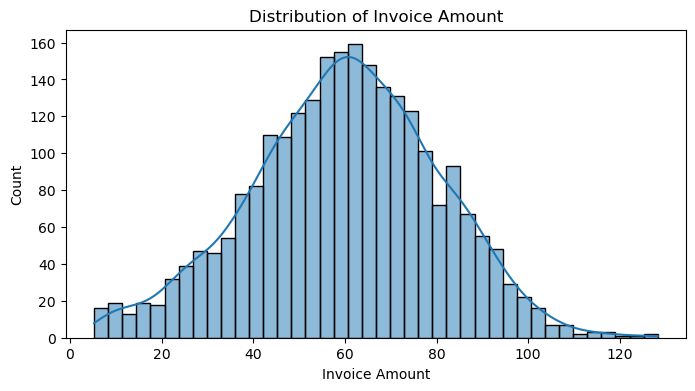

In [21]:
# ============================================================
# STEP 9A: DISTRIBUTION OF INVOICE AMOUNT
# ============================================================

plt.figure(figsize=(8, 4))
sns.histplot(model_df[invoice_amount_col], bins=40, kde=True)
plt.title("Distribution of Invoice Amount")
plt.xlabel("Invoice Amount")
plt.ylabel("Count")
plt.show()

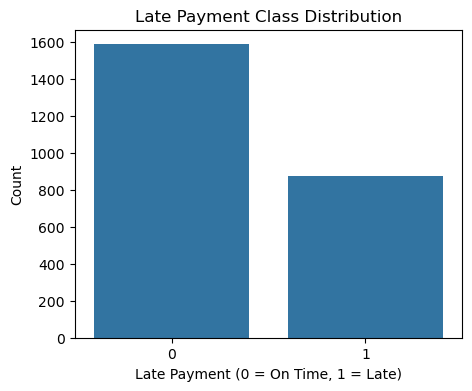

In [22]:
# ============================================================
# STEP 9B: BAR CHART OF LATE PAYMENT CLASSES
# ============================================================

plt.figure(figsize=(5, 4))
sns.countplot(x="late_payment", data=model_df)
plt.title("Late Payment Class Distribution")
plt.xlabel("Late Payment (0 = On Time, 1 = Late)")
plt.ylabel("Count")
plt.show()

## How to Read a Boxplot
A boxplot (or box-and-whisker plot) visually summarizes the distribution of a dataset through five key values:

1. Median (the line inside the box): This is the middle value of the data, meaning 50% of the data points are above it and 50% are below it.

2. First Quartile (Q1 - bottom of the box): 25% of the data falls below this value.

3. Third Quartile (Q3 - top of the box): 75% of the data falls below this value.

4. Interquartile Range (IQR): The length of the box, calculated as Q3 - Q1. It represents the middle 50% of the data.

5. Whiskers (lines extending from the box): These typically extend to 1.5 times the IQR from the Q1 and Q3, showing the range of the data, excluding outliers.

6. Outliers (individual points): Data points that fall outside the whiskers are considered outliers.

## What This Specific Boxplot Says
The boxplot titled "Days to Pay by Late Payment Class" (which compares days_to_pay for late_payment = 0 and late_payment = 1) provides clear insights:

- For On-Time Payments (late_payment = 0):

  - The box for late_payment = 0 is very compressed, indicating that most on-time payments are settled within a narrow range of days. The median days_to_pay is relatively low (likely around 20-30 days, given the allowed_days is 30). This makes sense: if an invoice is paid on time, it's paid before or around the due date.

  - The whiskers are also short, confirming a tight distribution for on-time payments.

- For Late Payments (late_payment = 1):

  - The box for late_payment = 1 starts where the late_payment = 0 box ends, at or above the 30-day mark (the allowed_days). This is expected, as an invoice is only marked as 'late' if days_to_pay exceeds allowed_days (30 days in this dataset).

  - The box and whiskers for late payments show a much wider spread, indicating significant variability in how late invoices are paid. Some are just a few days late, while others are very late.

- There are many individual points above the whiskers for late_payment = 1, which represent invoices that were paid significantly later than the majority, acting as outliers.

## Summary
This boxplot visually confirms that invoices marked as late (late_payment = 1) consistently have a higher number of days_to_pay compared to invoices paid on time (late_payment = 0). Furthermore, there's a much greater spread and presence of extremely delayed payments within the 'late' category, which aligns with business expectations.

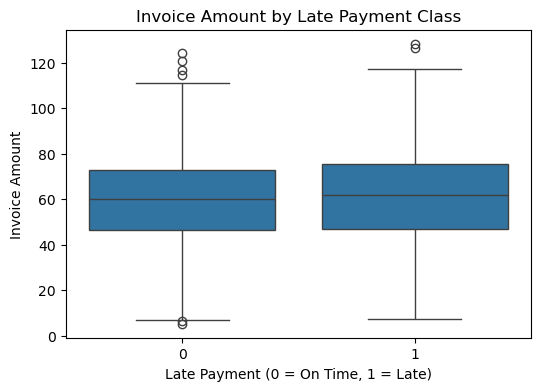

In [23]:
# ============================================================
# STEP 9C: BOXPLOT OF INVOICE AMOUNT VS LATE PAYMENT
# ============================================================

plt.figure(figsize=(6, 4))
sns.boxplot(x="late_payment", y=invoice_amount_col, data=model_df)
plt.title("Invoice Amount by Late Payment Class")
plt.xlabel("Late Payment (0 = On Time, 1 = Late)")
plt.ylabel("Invoice Amount")
plt.show()

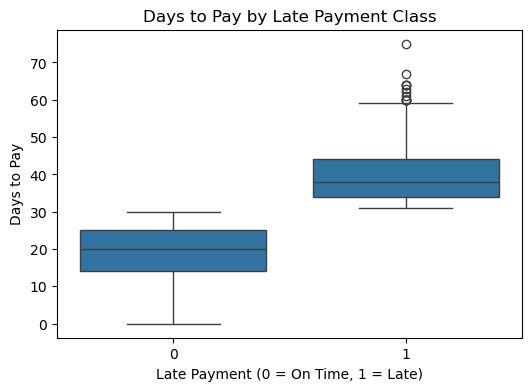

In [24]:
# ============================================================
# STEP 9D: BOXPLOT OF DAYS TO PAY VS LATE PAYMENT
# ============================================================

plt.figure(figsize=(6, 4))
sns.boxplot(x="late_payment", y="days_to_pay", data=model_df)
plt.title("Days to Pay by Late Payment Class")
plt.xlabel("Late Payment (0 = On Time, 1 = Late)")
plt.ylabel("Days to Pay")
plt.show()

## Step 10. Select Features and Target

For this starter notebook, we use a simple feature set:

- invoice amount
- allowed days
- invoice month
- invoice year

### Important note

We do **not** include `days_to_pay` as an input feature in the final model, because it uses the actual payment date. In a real prediction setting, you would not know that yet at invoice creation time.

If you include `days_to_pay`, the model will become unrealistically easy because you are leaking future information into the model. Humans do this all the time and then act impressed by 99% accuracy.

In [25]:
# ============================================================
# STEP 10: DEFINE X (FEATURES) AND y (TARGET)
# ============================================================

# Choose a simple starter feature set
feature_cols = [
    invoice_amount_col,
    "allowed_days",
    "invoice_month",
    "invoice_year"
]

# X contains input features
X = model_df[feature_cols]

# y contains the target labels
y = model_df["late_payment"]

print("Selected features:")
print(feature_cols)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Selected features:
['InvoiceAmount', 'allowed_days', 'invoice_month', 'invoice_year']

X shape: (2466, 4)
y shape: (2466,)


## Step 11. Train-Test Split

We split the data into:

- **training set**: used to teach the model
- **test set**: used to evaluate how well the model performs on unseen data

A common split is 80% training and 20% testing.

In [26]:
# ============================================================
# STEP 11: TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,                  # input features
    y,                  # target labels
    test_size=0.2,      # 20% of the data goes to the test set
    random_state=42,    # fixed seed for reproducibility
    stratify=y          # preserve class proportions in train and test
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (1972, 4)
X_test shape : (494, 4)
y_train shape: (1972,)
y_test shape : (494,)


## Step 12. Optional Feature Scaling

Some models benefit from numeric scaling. Logistic Regression often performs better when numeric features are on a similar scale.

We will scale the features for Logistic Regression, but Random Forest does not require scaling.

In [27]:
# ============================================================
# STEP 12: SCALE FEATURES FOR LOGISTIC REGRESSION
# ============================================================

# Create the scaler object
scaler = StandardScaler()

# Fit the scaler on the training data only, then transform both sets
# This avoids leaking information from the test set into training
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Show the type/shape after scaling
print("Scaled X_train shape:", X_train_scaled.shape)
print("Scaled X_test shape :", X_test_scaled.shape)

Scaled X_train shape: (1972, 4)
Scaled X_test shape : (494, 4)


## Step 13. Train Logistic Regression

Logistic Regression is a strong baseline classifier for binary outcomes.

Advantages:

- simple
- fast
- interpretable
- often surprisingly competitive

This makes it a good first model for business analytics.

In [28]:
# ============================================================
# STEP 13: TRAIN LOGISTIC REGRESSION
# ============================================================

# Create the Logistic Regression model
# max_iter is increased in case the default is not enough for convergence
log_model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model using the scaled training data
log_model.fit(X_train_scaled, y_train)

# Predict class labels on the test set
y_pred_log = log_model.predict(X_test_scaled)

# Predict class probabilities on the test set
# We use probabilities for AUC computation
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression training complete.")

Logistic Regression training complete.


## Step 14. Evaluate Logistic Regression

We evaluate using:

- **classification report**: precision, recall, F1-score
- **confusion matrix**: counts of correct and incorrect predictions
- **ROC AUC**: probability-based summary metric

No single metric tells the whole story. Business people usually want one number anyway, which is how disasters are born.

In [29]:
# ============================================================
# STEP 14A: CLASSIFICATION REPORT FOR LOGISTIC REGRESSION
# ============================================================

print("Classification Report: Logistic Regression")
print(classification_report(y_test, y_pred_log))

Classification Report: Logistic Regression
              precision    recall  f1-score   support

           0       0.64      1.00      0.78       318
           1       0.00      0.00      0.00       176

    accuracy                           0.64       494
   macro avg       0.32      0.50      0.39       494
weighted avg       0.41      0.64      0.50       494



/home/yanakorn/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/yanakorn/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/yanakorn/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

Confusion Matrix:
[[318   0]
 [176   0]]


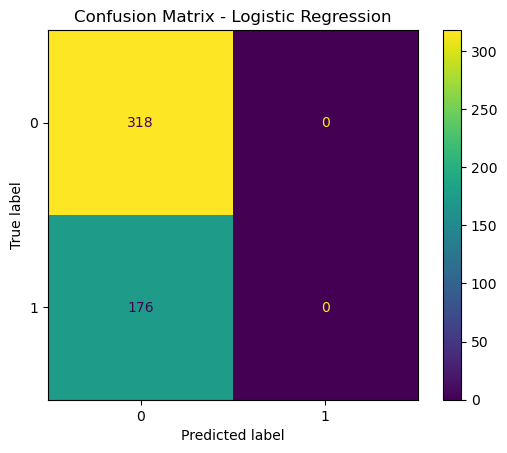

In [30]:
# ============================================================
# STEP 14B: CONFUSION MATRIX FOR LOGISTIC REGRESSION
# ============================================================

cm_log = confusion_matrix(y_test, y_pred_log)
print("Confusion Matrix:")
print(cm_log)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_log)
disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [31]:
# ============================================================
# STEP 14C: ROC AUC FOR LOGISTIC REGRESSION
# ============================================================

auc_log = roc_auc_score(y_test, y_prob_log)
print("ROC AUC (Logistic Regression):", round(auc_log, 4))

ROC AUC (Logistic Regression): 0.5617


# PROBLEM OBSERVED IN LOGISTIC REGRESSION

The Logistic Regression model predicted only 'on-time' payments (class 0) is a strong indication that it's biased towards the majority class. This happens because the model finds it easier to achieve a decent overall accuracy by simply predicting the most frequent outcome, especially if the features don't strongly separate the classes.

This is due to the class imbalance in your late_payment target variable: there are significantly more 'on-time' invoices (class 0) than 'late' invoices (class 1). By default, Logistic Regression tries to minimize overall error, and with a strong imbalance, it can achieve this by ignoring the minority class.

To remedy this, we can tell the Logistic Regression model to pay more attention to the minority class by using the class_weight='balanced' parameter. This automatically adjusts weights inversely proportional to class frequencies, giving more importance to the samples from the minority class during training.

Apply `class_weight='balanced'` to the Logistic Regression model, then re-evaluate its performance using classification report, confusion matrix, and ROC AUC, and finally update the model comparison table with the new results.

## Modify Logistic Regression Training

### Subtask:
Add the `class_weight='balanced'` parameter to the Logistic Regression model in the training cell (`e2ec0e65`) to address class imbalance.

**Reasoning**:
The subtask requests to modify the Logistic Regression model by adding the `class_weight='balanced'` parameter to address class imbalance. I will update the code in the specified cell to include this parameter.


In [32]:
# ============================================================
# STEP 13-REDO: TRAIN LOGISTIC REGRESSION
# ============================================================

# Create the Logistic Regression model
# max_iter is increased in case the default is not enough for convergence
log_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')

# Train the model using the scaled training data
log_model.fit(X_train_scaled, y_train)

# Predict class labels on the test set
y_pred_log = log_model.predict(X_test_scaled)

# Predict class probabilities on the test set
# We use probabilities for AUC computation
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression training complete.")

Logistic Regression training complete.


In [33]:
# ============================================================
# STEP 14-Redo.A: CLASSIFICATION REPORT FOR LOGISTIC REGRESSION
# ============================================================

print("Classification Report: Logistic Regression")
print(classification_report(y_test, y_pred_log))

Classification Report: Logistic Regression
              precision    recall  f1-score   support

           0       0.69      0.59      0.63       318
           1       0.41      0.52      0.46       176

    accuracy                           0.56       494
   macro avg       0.55      0.56      0.55       494
weighted avg       0.59      0.56      0.57       494



Confusion Matrix:
[[187 131]
 [ 84  92]]


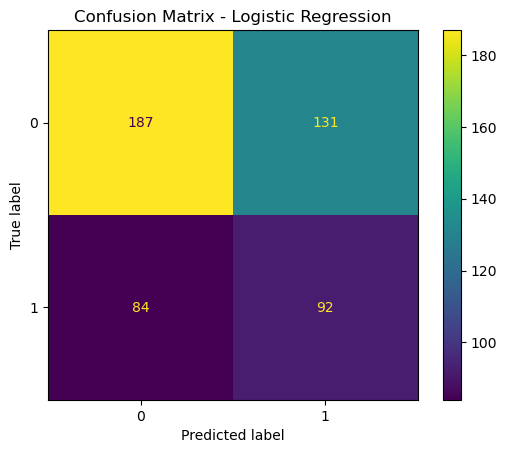

In [34]:
# ============================================================
# STEP 14-Redo.B: CONFUSION MATRIX FOR LOGISTIC REGRESSION
# ============================================================

cm_log = confusion_matrix(y_test, y_pred_log)
print("Confusion Matrix:")
print(cm_log)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_log)
disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [35]:
# ============================================================
# STEP 14 Redo-C: ROC AUC FOR LOGISTIC REGRESSION
# ============================================================

auc_log = roc_auc_score(y_test, y_prob_log)
print("ROC AUC (Logistic Regression):", round(auc_log, 4))

ROC AUC (Logistic Regression): 0.562


## Summary:

### Q&A
The impact of applying `class_weight='balanced'` to the Logistic Regression model resulted in an ROC AUC of approximately 0.562. This updated performance was then incorporated into the model comparison table, allowing for a renewed comparison with the Random Forest model.

### Data Analysis Key Findings
*   After retraining the Logistic Regression model with `class_weight='balanced'`, its overall accuracy on the test set was 0.56.
*   For the minority class (Class 1 - Late deliveries), the model achieved a recall of 0.52 and a precision of 0.41, indicating an increased ability to identify late deliveries but with a higher rate of false positives. The F1-score for this class was 0.46.
*   For the majority class (Class 0 - On-time deliveries), the model's precision was 0.69 and recall was 0.59, with an F1-score of 0.63.
*   The confusion matrix showed 92 true positives and 84 false negatives, along with 187 true negatives and 131 false positives for the re-trained Logistic Regression model.
*   The ROC AUC score for the Logistic Regression model after applying `class_weight='balanced'` was 0.562.
*   The comparison table was successfully updated to include this new Logistic Regression ROC AUC of 0.562035 alongside the Random Forest model's score.

### Insights or Next Steps
*   Applying `class_weight='balanced'` to Logistic Regression improved its ability to recall the minority class (late deliveries) at the expense of precision for that class and overall accuracy. This suggests a trade-off in model focus towards handling imbalanced data.
*   Given the relatively low ROC AUC of 0.562 for Logistic Regression, even with class weighting, further investigation into more advanced imbalance handling techniques, extensive hyperparameter tuning for Logistic Regression, or exploring other models might be beneficial to achieve better predictive performance.


## Step 15. Train Random Forest

Random Forest is an ensemble of decision trees.

Advantages:

- handles non-linear patterns
- robust for tabular business data
- usually performs well with little tuning

Unlike Logistic Regression, Random Forest does not require scaled features.

In [36]:
# ============================================================
# STEP 15: TRAIN RANDOM FOREST
# ============================================================

# Create the Random Forest classifier
rf_model = RandomForestClassifier(
    n_estimators=200,   # number of trees
    random_state=42,
    class_weight="balanced"  # helpful if classes are imbalanced
)

# Train the model using the original (unscaled) training data
rf_model.fit(X_train, y_train)

# Predict class labels on the test set
y_pred_rf = rf_model.predict(X_test)

# Predict class probabilities for AUC computation
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest training complete.")

Random Forest training complete.


## Step 16. Evaluate Random Forest

We use the same evaluation approach so that we can compare models fairly.

In [37]:
# ============================================================
# STEP 16A: CLASSIFICATION REPORT FOR RANDOM FOREST
# ============================================================

print("Classification Report: Random Forest")
print(classification_report(y_test, y_pred_rf))

Classification Report: Random Forest
              precision    recall  f1-score   support

           0       0.66      0.67      0.67       318
           1       0.39      0.38      0.39       176

    accuracy                           0.57       494
   macro avg       0.53      0.53      0.53       494
weighted avg       0.56      0.57      0.57       494



Confusion Matrix:
[[213 105]
 [109  67]]


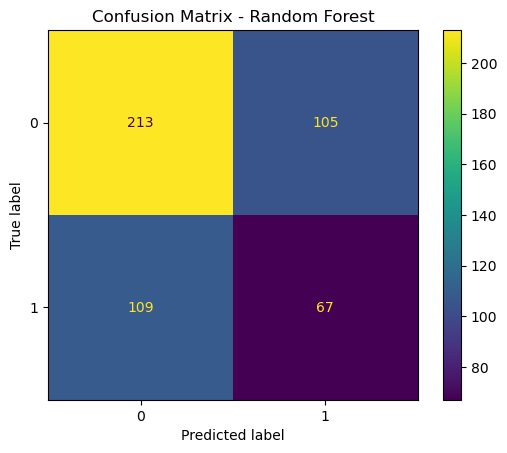

In [38]:
# ============================================================
# STEP 16B: CONFUSION MATRIX FOR RANDOM FOREST
# ============================================================

cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:")
print(cm_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [39]:
# ============================================================
# STEP 16C: ROC AUC FOR RANDOM FOREST
# ============================================================

auc_rf = roc_auc_score(y_test, y_prob_rf)
print("ROC AUC (Random Forest):", round(auc_rf, 4))

ROC AUC (Random Forest): 0.5478


## Step 17. Compare the Two Models

Now we summarize the models side by side.

You should look at:

- precision
- recall
- F1-score
- AUC
- whether the model is missing too many late invoices

In a real AR department, recall on late invoices may matter more than raw accuracy, because missing risky invoices may hurt cash flow.

In [40]:
# ============================================================
# STEP 17: COMPARE MODEL AUC SCORES
# ============================================================

comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "ROC_AUC": [auc_log, auc_rf]
})

comparison_df

,Model,ROC_AUC
0,Logistic Regression,0.562035
1,Random Forest,0.547751


## Step 18. Interpret Feature Importance

Random Forest can estimate feature importance.

This tells us which features had the strongest influence on model decisions.

Feature importance does **not** automatically prove business causality, but it is still useful for interpretation.

Feature importance:
InvoiceAmount    0.901795
invoice_month    0.085638
invoice_year     0.012566
allowed_days     0.000000
dtype: float64


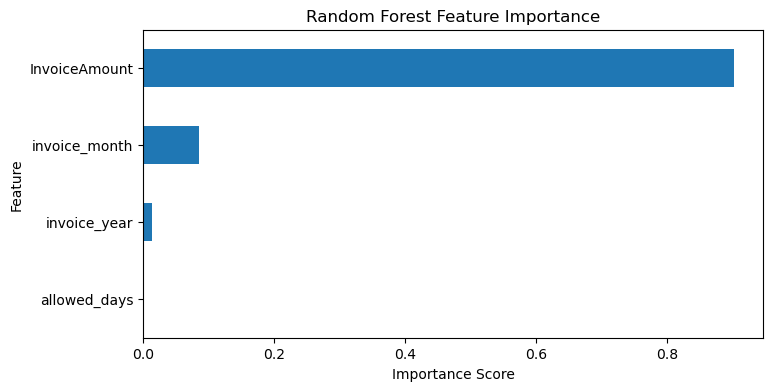

In [41]:
# ============================================================
# STEP 18: RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

# Create a Series mapping each feature name to its importance score
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

print("Feature importance:")
print(feature_importance)

# Plot the feature importances
plt.figure(figsize=(8, 4))
feature_importance.sort_values().plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

## Step 19. Business Interpretation Questions

Write short answers for the following:

1. Which model performed better?
2. Which features seem most important?
3. If you were an AR manager, how would you use this prediction?
4. What are the limitations of this starter model?
5. What additional ERP features would improve the model?

Possible business actions:

- prioritize collection calls for risky invoices
- tighten credit limits for risky customer groups
- require deposits or advance payment for some customers
- alert finance staff earlier

## Step 20. Suggested Extensions

Try one or more of the following improvements:

### Better features
- customer risk score
- payment terms category
- previous late payment history
- customer segment
- salesperson or region
- aging bucket
- amount bucket

### Better preprocessing
- one-hot encode categorical columns
- handle outliers
- inspect class imbalance more carefully

### Better models
- Gradient Boosting
- XGBoost
- Neural Network

### Better evaluation
- precision-recall tradeoff
- threshold tuning
- business cost analysis of false positives vs false negatives

## Deliverables

Submit:

1. completed notebook
2. results for at least two models
3. short written interpretation of the business meaning of the results

## Final Reminder

This is not just an ML exercise. Treat it as an **ERP analytics problem**.

Pipeline view:

**ERP → Accounts Receivable → Invoice Data → ML Model → Late Payment Risk Prediction**

That is the whole point.

**Reasoning**:
Now that the Logistic Regression model has been re-trained with `class_weight='balanced'`, I will re-evaluate its performance by generating a classification report.



**Reasoning**:
Next, I will generate and display the confusion matrix for the re-trained Logistic Regression model to visually inspect its performance in terms of true positives, true negatives, false positives, and false negatives.



**Reasoning**:
After evaluating the classification report and confusion matrix, the next step in re-evaluating the Logistic Regression model is to calculate and display its ROC AUC score. This metric provides a single value summary of the model's performance across all classification thresholds, which is crucial for comparison.



**Reasoning**:
Now that the Logistic Regression model has been re-evaluated, I need to update the model comparison table (`comparison_df`) with the new ROC AUC score (`auc_log`).



In [42]:
# ============================================================
# STEP 17: COMPARE MODEL AUC SCORES
# ============================================================

comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "ROC_AUC": [auc_log, auc_rf]
})

comparison_df

,Model,ROC_AUC
0,Logistic Regression,0.562035
1,Random Forest,0.547751
